## Project 50: National Waste Recycling Rate Analysis

This notebook will guide us through an end-to-end data analytics workflow to evaluate regional waste management practices in India.

### Step 1: Data Ingestion and Initial Inspection

We'll start by loading the main dataset, `Waste_Management_and_Recycling_India.csv`, into a pandas DataFrame and examine its structure and initial content.

In [2]:
import pandas as pd

# Load the dataset
df_waste = pd.read_csv('/content/Waste_Management_and_Recycling_India.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df_waste.head())

# Display basic information about the DataFrame (columns, non-null counts, dtypes)
print("\nDataFrame Information:")
display(df_waste.info())

# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df_waste.describe())

First 5 rows of the dataset:


,City/District,Waste Type,Waste Generated (Tons/Day),Recycling Rate (%),Population Density (People/km²),Municipal Efficiency Score (1-10),Disposal Method,Cost of Waste Management (₹/Ton),Awareness Campaigns Count,Landfill Name,"Landfill Location (Lat, Long)",Landfill Capacity (Tons),Year
0,Mumbai,Plastic,6610,68,11191,9,Composting,3056,14,Mumbai Landfill,"22.4265, 77.4931",45575,2019
1,Mumbai,Organic,1181,56,11191,5,Composting,2778,12,Mumbai Landfill,"22.4265, 77.4931",45575,2019
2,Mumbai,E-Waste,8162,53,11191,8,Incineration,3390,13,Mumbai Landfill,"22.4265, 77.4931",45575,2019
3,Mumbai,Construction,8929,56,11191,5,Landfill,1498,14,Mumbai Landfill,"22.4265, 77.4931",45575,2019
4,Mumbai,Hazardous,5032,44,11191,7,Recycling,2221,16,Mumbai Landfill,"22.4265, 77.4931",45575,2019



DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   City/District                      850 non-null    object
 1   Waste Type                         850 non-null    object
 2   Waste Generated (Tons/Day)         850 non-null    int64 
 3   Recycling Rate (%)                 850 non-null    int64 
 4   Population Density (People/km²)    850 non-null    int64 
 5   Municipal Efficiency Score (1-10)  850 non-null    int64 
 6   Disposal Method                    850 non-null    object
 7   Cost of Waste Management (₹/Ton)   850 non-null    int64 
 8   Awareness Campaigns Count          850 non-null    int64 
 9   Landfill Name                      850 non-null    object
 10  Landfill Location (Lat, Long)      850 non-null    object
 11  Landfill Capacity (Tons)           850 non-null

None


Descriptive Statistics:


,Waste Generated (Tons/Day),Recycling Rate (%),Population Density (People/km²),Municipal Efficiency Score (1-10),Cost of Waste Management (₹/Ton),Awareness Campaigns Count,Landfill Capacity (Tons),Year
count,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000
mean,5262.249412,57.076471,13489.705882,7.400000,2778.458824,9.904706,58934.617647,2021.000000
std,2786.984735,16.129994,6631.081494,1.722162,1276.325630,6.070772,19413.627292,1.415046
min,511.000000,30.000000,2335.000000,5.000000,503.000000,0.000000,22690.000000,2019.000000
25%,2865.750000,43.000000,7927.000000,6.000000,1647.500000,5.000000,45575.000000,2020.000000
50%,5283.000000,56.000000,12579.500000,7.000000,2853.000000,10.000000,61038.500000,2021.000000
75%,7757.250000,71.000000,19087.000000,9.000000,3855.000000,15.000000,71127.000000,2022.000000
max,9980.000000,85.000000,24032.000000,10.000000,4999.000000,20.000000,98646.000000,2023.000000


### Step 2: Data Standardization and Cleaning (Checking for Inconsistencies)

Since `df_waste.info()` indicated no missing values, we'll now focus on standardizing records. This involves checking for inconsistencies in categorical columns to ensure data integrity. We will inspect unique values in 'Waste Type', 'Disposal Method', and 'City/District'.

In [3]:
print("\nUnique values in 'Waste Type':")
print(df_waste['Waste Type'].unique())

print("\nUnique values in 'Disposal Method':")
print(df_waste['Disposal Method'].unique())

print("\nUnique values in 'City/District':")
# Displaying only the first 20 unique cities for brevity, as there might be many.
print(df_waste['City/District'].unique()[:20])
print(f"Total unique cities: {len(df_waste['City/District'].unique())}")


Unique values in 'Waste Type':
['Plastic' 'Organic' 'E-Waste' 'Construction' 'Hazardous']

Unique values in 'Disposal Method':
['Composting' 'Incineration' 'Landfill' 'Recycling']

Unique values in 'City/District':
['Mumbai' 'Delhi' 'Bengaluru' 'Chennai' 'Kolkata' 'Hyderabad' 'Pune'
 'Ahmedabad' 'Jaipur' 'Lucknow' 'Surat' 'Kanpur' 'Nagpur' 'Patna' 'Bhopal'
 'Thiruvananthapuram' 'Indore' 'Vadodara' 'Guwahati' 'Coimbatore']
Total unique cities: 34


### Step 2.1: Clean Column Names

To facilitate easier data manipulation and analysis, we will clean the column names by removing special characters, units, and converting them to a consistent snake_case format.

In [4]:
df_waste.columns = df_waste.columns.str.replace(r'[^a-zA-Z0-9_\s]', '', regex=True) # Remove special characters except underscore and space
df_waste.columns = df_waste.columns.str.lower() # Convert to lowercase
df_waste.columns = df_waste.columns.str.replace(' ', '_', regex=False) # Replace spaces with underscores

# Rename specific columns for clarity and consistency
df_waste = df_waste.rename(columns={
    'waste_generated_tonsday': 'waste_generated_tons_day',
    'recycling_rate': 'recycling_rate_percent',
    'population_density_peoplekm': 'population_density_people_per_km2',
    'cost_of_waste_management_ton': 'cost_of_waste_management_per_ton',
    'municipal_efficiency_score_110': 'municipal_efficiency_score'
})

# Fix the column name that ended with an underscore accidentally
df_waste.columns = df_waste.columns.str.replace('recycling_rate_', 'recycling_rate_percent', regex=False)

print("Cleaned Column Names:")
print(df_waste.columns.tolist())

# Display the first few rows with new column names to confirm
print("\nDataFrame head with cleaned column names:")
display(df_waste.head())

Cleaned Column Names:
['citydistrict', 'waste_type', 'waste_generated_tons_day', 'recycling_rate_percent', 'population_density_people_per_km2', 'municipal_efficiency_score', 'disposal_method', 'cost_of_waste_management_per_ton', 'awareness_campaigns_count', 'landfill_name', 'landfill_location_lat_long', 'landfill_capacity_tons', 'year']

DataFrame head with cleaned column names:


,citydistrict,waste_type,waste_generated_tons_day,recycling_rate_percent,population_density_people_per_km2,municipal_efficiency_score,disposal_method,cost_of_waste_management_per_ton,awareness_campaigns_count,landfill_name,landfill_location_lat_long,landfill_capacity_tons,year
0,Mumbai,Plastic,6610,68,11191,9,Composting,3056,14,Mumbai Landfill,"22.4265, 77.4931",45575,2019
1,Mumbai,Organic,1181,56,11191,5,Composting,2778,12,Mumbai Landfill,"22.4265, 77.4931",45575,2019
2,Mumbai,E-Waste,8162,53,11191,8,Incineration,3390,13,Mumbai Landfill,"22.4265, 77.4931",45575,2019
3,Mumbai,Construction,8929,56,11191,5,Landfill,1498,14,Mumbai Landfill,"22.4265, 77.4931",45575,2019
4,Mumbai,Hazardous,5032,44,11191,7,Recycling,2221,16,Mumbai Landfill,"22.4265, 77.4931",45575,2019


### Step 3: Exploratory Data Analysis and Feature Engineering

Now, we will compute vital metrics as per the project instructions. We'll start with regional recycling rates, per capita waste generation rates, and recovery rates by material category.

#### 3.1 Regional Recycling Rates

First, we need to calculate the actual amount of waste recycled and the total waste generated for each `citydistrict` and `year`. Then, we can compute the overall regional recycling rate using the formula: $(\text{Total Recycled Waste} / \text{Total Waste Generated}) \times 100$.

In [5]:
# Calculate 'recycled_waste_tons_day' for each row
df_waste['recycled_waste_tons_day'] = df_waste['waste_generated_tons_day'] * (df_waste['recycling_rate_percent'] / 100)

# Group by city/district and year to get total waste generated and total recycled waste
regional_waste_summary = df_waste.groupby(['citydistrict', 'year']).agg(
    total_waste_generated_tons_day=('waste_generated_tons_day', 'sum'),
    total_recycled_waste_tons_day=('recycled_waste_tons_day', 'sum')
).reset_index()

# Calculate regional recycling rate
regional_waste_summary['regional_recycling_rate_percent'] = (
    regional_waste_summary['total_recycled_waste_tons_day'] / regional_waste_summary['total_waste_generated_tons_day']
) * 100

print("Regional Waste Summary with Recycling Rates (first 5 rows):")
display(regional_waste_summary.head())

Regional Waste Summary with Recycling Rates (first 5 rows):


,citydistrict,year,total_waste_generated_tons_day,total_recycled_waste_tons_day,regional_recycling_rate_percent
0,Agra,2019,34463,15997.67,46.419842
1,Agra,2020,24211,16806.57,69.417083
2,Agra,2021,37337,16716.86,44.772906
3,Agra,2022,15703,10705.70,68.176145
4,Agra,2023,23151,15576.05,67.280247


#### 3.2 Per Capita Waste Generation Rates

To calculate per capita waste generation rates, we need population data. Since we have `population_density_people_per_km2` and not total population, we will calculate 'waste generated per unit of population density' as a proxy. First, we will check for consistency of `population_density_people_per_km2` within `citydistrict` and `year` groups, then integrate it into our `regional_waste_summary` and perform the calculation.

In [6]:
# Check if population_density is consistent within city/year groups
population_density_check = df_waste.groupby(['citydistrict', 'year'])['population_density_people_per_km2'].nunique()
inconsistent_densities = population_density_check[population_density_check > 1]

if not inconsistent_densities.empty:
    print("Warning: Inconsistency found in population density within city/year groups:")
    print(inconsistent_densities)
    # For simplicity, we'll take the mean if inconsistencies exist, but ideally, this would be investigated.
    city_year_population_density = df_waste.groupby(['citydistrict', 'year'])['population_density_people_per_km2'].mean().reset_index()
else:
    print("Population density is consistent within city/year groups. Proceeding with average.")
    city_year_population_density = df_waste.groupby(['citydistrict', 'year'])['population_density_people_per_km2'].first().reset_index()

# Merge population density into the regional_waste_summary
regional_waste_summary = pd.merge(
    regional_waste_summary,
    city_year_population_density,
    on=['citydistrict', 'year'],
    how='left'
)

# Calculate per capita waste generation rate (per person-density-unit)
# Note: This is per unit of population density, not per actual person, due to data limitations.
regional_waste_summary['waste_generated_per_person_density_unit'] = (
    regional_waste_summary['total_waste_generated_tons_day'] / regional_waste_summary['population_density_people_per_km2']
)

print("Regional Waste Summary with Per Capita Waste Generation (first 5 rows):")
display(regional_waste_summary.head())

Population density is consistent within city/year groups. Proceeding with average.
Regional Waste Summary with Per Capita Waste Generation (first 5 rows):


,citydistrict,year,total_waste_generated_tons_day,total_recycled_waste_tons_day,regional_recycling_rate_percent,population_density_people_per_km2,waste_generated_per_person_density_unit
0,Agra,2019,34463,15997.67,46.419842,4629,7.445021
1,Agra,2020,24211,16806.57,69.417083,4629,5.230287
2,Agra,2021,37337,16716.86,44.772906,4629,8.065889
3,Agra,2022,15703,10705.70,68.176145,4629,3.392309
4,Agra,2023,23151,15576.05,67.280247,4629,5.001296


#### 3.3 Recovery Rates Broken Down by Material Category

Next, we will calculate the recovery rates for each material category (waste type). This will help us understand which materials are being recycled more efficiently and identify potential areas for improvement.

In [7]:
# Group by waste_type to get total generated and recycled waste for each material
material_recovery_summary = df_waste.groupby('waste_type').agg(
    total_waste_generated_material=('waste_generated_tons_day', 'sum'),
    total_recycled_waste_material=('recycled_waste_tons_day', 'sum')
).reset_index()

# Calculate material recovery rate
material_recovery_summary['material_recovery_rate_percent'] = (
    material_recovery_summary['total_recycled_waste_material'] / material_recovery_summary['total_waste_generated_material']
) * 100

print("Material Recovery Rates (first 5 rows):")
display(material_recovery_summary.head())

Material Recovery Rates (first 5 rows):


,waste_type,total_waste_generated_material,total_recycled_waste_material,material_recovery_rate_percent
0,Construction,889098,505486.31,56.853835
1,E-Waste,897026,500073.64,55.747954
2,Hazardous,841408,475102.72,56.465201
3,Organic,900664,506961.51,56.287529
4,Plastic,944716,552574.66,58.491087


### Step 4: Exploratory Data Analysis (EDA) and Preliminary Insights

With our key metrics calculated, we can now perform some preliminary EDA to identify trends, top/bottom performers, and potential areas for improvement. This will inform the insights for our final dashboard and report.

#### 4.1 Regional Recycling Rate Analysis

Let's visualize the average regional recycling rates to identify which cities/districts are performing well and which are lagging.

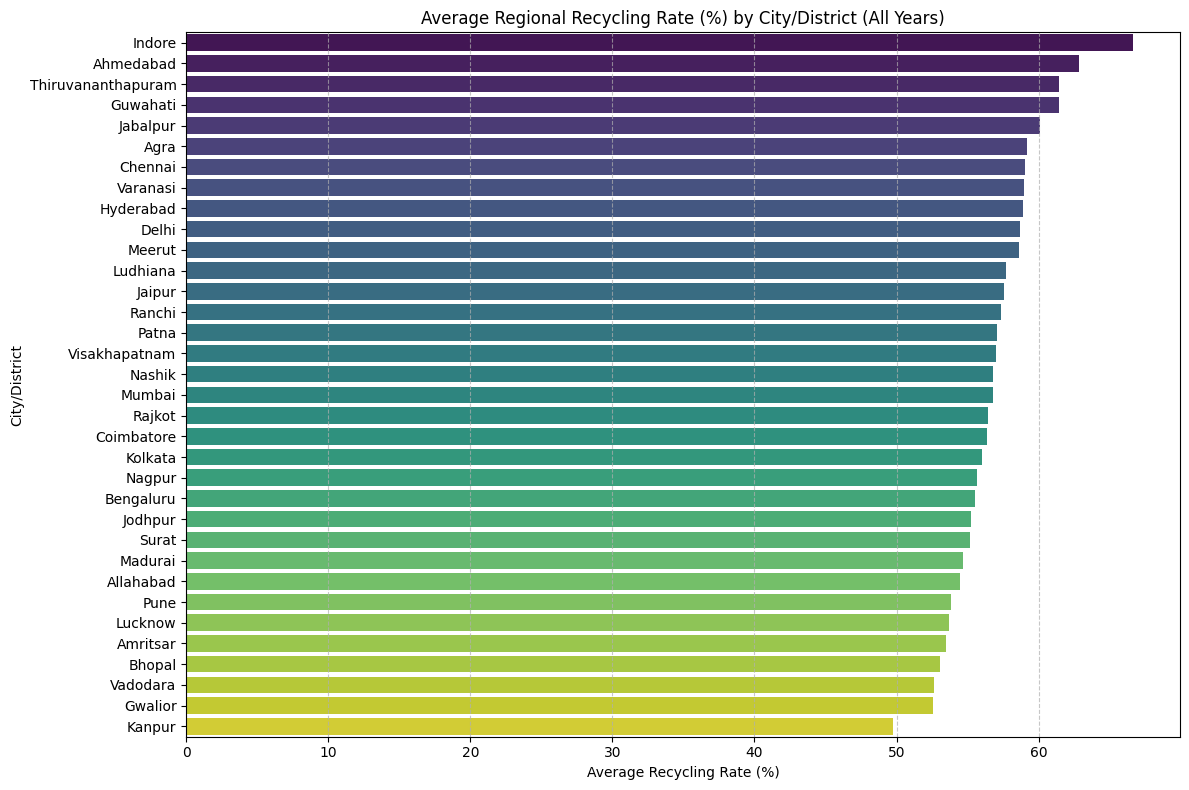


Top 5 Cities by Average Recycling Rate:


,regional_recycling_rate_percent
citydistrict,
Indore,66.624615
Ahmedabad,62.851871
Thiruvananthapuram,61.448203
Guwahati,61.444058
Jabalpur,60.097093



Bottom 5 Cities by Average Recycling Rate:


,regional_recycling_rate_percent
citydistrict,
Amritsar,53.471495
Bhopal,53.063715
Vadodara,52.642470
Gwalior,52.556260
Kanpur,49.717028


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average regional recycling rate per city
avg_regional_recycling = regional_waste_summary.groupby('citydistrict')['regional_recycling_rate_percent'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=avg_regional_recycling.values, y=avg_regional_recycling.index, palette='viridis', hue=avg_regional_recycling.index, legend=False)
plt.title('Average Regional Recycling Rate (%) by City/District (All Years)')
plt.xlabel('Average Recycling Rate (%)')
plt.ylabel('City/District')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTop 5 Cities by Average Recycling Rate:")
display(avg_regional_recycling.head())

print("\nBottom 5 Cities by Average Recycling Rate:")
display(avg_regional_recycling.tail())

#### 4.2 Material Recovery Rate Analysis

To identify specific areas of improvement, let's visualize the recovery rates for each waste type. This will highlight which materials are being effectively recycled and which require more attention.

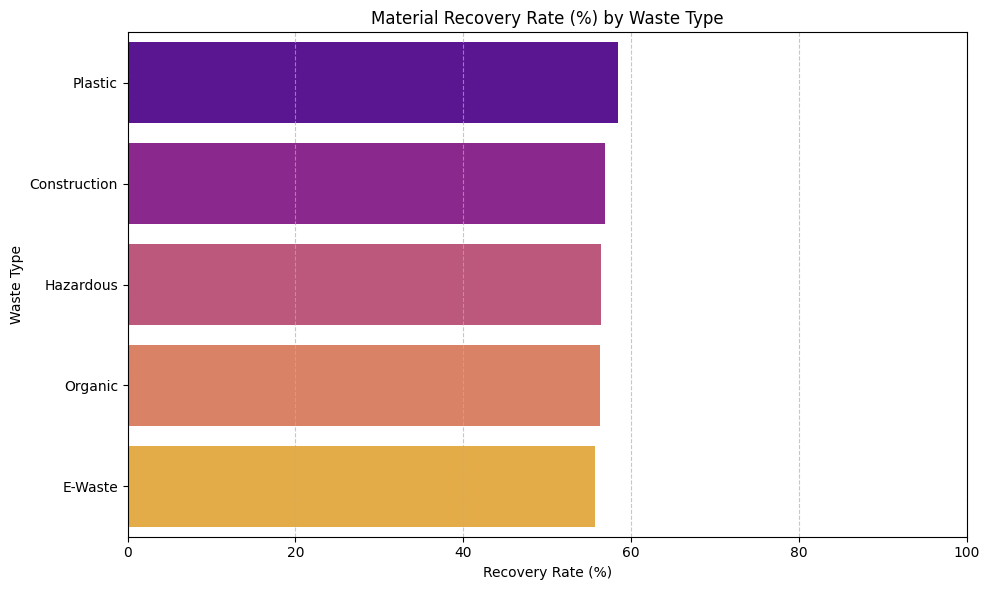


Material Recovery Rates:


,waste_type,total_waste_generated_material,total_recycled_waste_material,material_recovery_rate_percent
4,Plastic,944716,552574.66,58.491087
0,Construction,889098,505486.31,56.853835
2,Hazardous,841408,475102.72,56.465201
3,Organic,900664,506961.51,56.287529
1,E-Waste,897026,500073.64,55.747954


In [9]:
# Sort material_recovery_summary by material_recovery_rate_percent for better visualization
material_recovery_summary_sorted = material_recovery_summary.sort_values(by='material_recovery_rate_percent', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='material_recovery_rate_percent', y='waste_type', data=material_recovery_summary_sorted, palette='plasma', hue='waste_type', legend=False)
plt.title('Material Recovery Rate (%) by Waste Type')
plt.xlabel('Recovery Rate (%)')
plt.ylabel('Waste Type')
plt.xlim(0, 100) # Assuming recovery rates are between 0 and 100
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nMaterial Recovery Rates:")
display(material_recovery_summary_sorted)

#### 4.3 Trends in Waste Generation and Recycling Rates Over Time

Understanding how waste generation and recycling rates have evolved over the years is crucial for identifying progress, stagnation, or decline in waste management efforts. We will visualize these trends at a national level to gain a broader perspective.

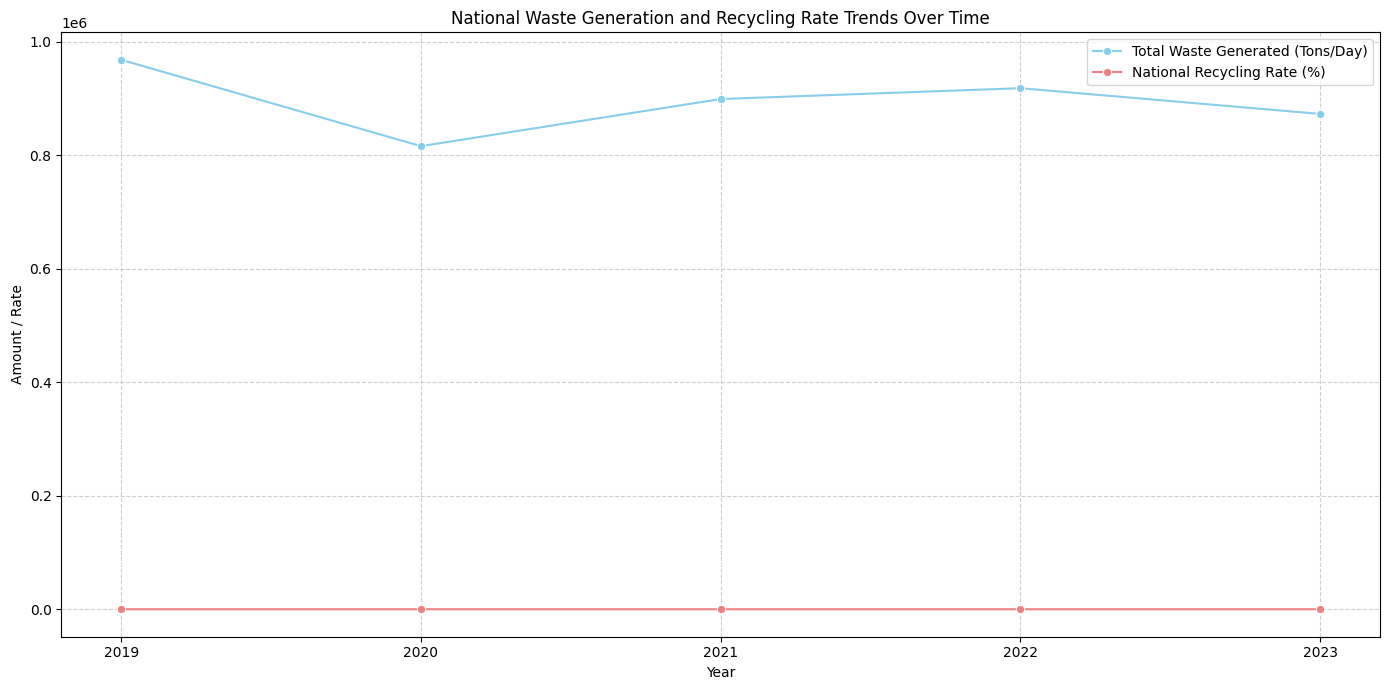


National Waste Trends Over Time:


,year,total_waste_generated_tons_day,total_recycled_waste_tons_day,national_recycling_rate_percent
0,2019,967885,533011.80,55.069745
1,2020,815784,471093.37,57.747317
2,2021,898779,516760.57,57.495844
3,2022,917891,515897.90,56.204702
4,2023,872573,503435.20,57.695482


In [10]:
# Group by year to get total waste generated and total recycled waste nationally
national_waste_trends = regional_waste_summary.groupby('year').agg(
    total_waste_generated_tons_day=('total_waste_generated_tons_day', 'sum'),
    total_recycled_waste_tons_day=('total_recycled_waste_tons_day', 'sum')
).reset_index()

# Calculate national recycling rate over time
national_waste_trends['national_recycling_rate_percent'] = (
    national_waste_trends['total_recycled_waste_tons_day'] / national_waste_trends['total_waste_generated_tons_day']
) * 100

plt.figure(figsize=(14, 7))

# Plot total waste generated
sns.lineplot(x='year', y='total_waste_generated_tons_day', data=national_waste_trends, marker='o', label='Total Waste Generated (Tons/Day)', color='skyblue')

# Plot national recycling rate
sns.lineplot(x='year', y='national_recycling_rate_percent', data=national_waste_trends, marker='o', label='National Recycling Rate (%)', color='lightcoral')

plt.title('National Waste Generation and Recycling Rate Trends Over Time')
plt.xlabel('Year')
plt.ylabel('Amount / Rate')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(national_waste_trends['year'])
plt.legend()
plt.tight_layout()
plt.show()

print("\nNational Waste Trends Over Time:")
display(national_waste_trends)

#### 4.4 Impact of Municipal Efficiency on Recycling Rates

To identify potential drivers of recycling success, let's explore the relationship between the `municipal_efficiency_score` and `recycling_rate_percent`. A higher efficiency score might correlate with better recycling performance.

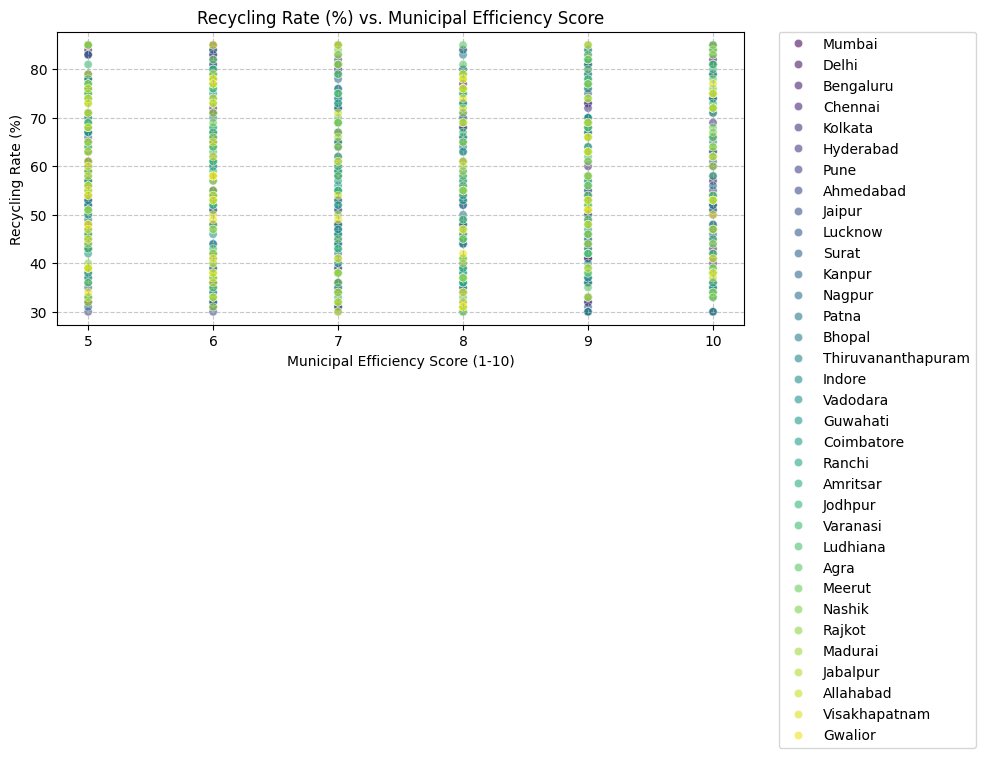

Correlation between Municipal Efficiency Score and Recycling Rate: -0.03


In [11]:
# Analyze the relationship between Municipal Efficiency Score and Recycling Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(x='municipal_efficiency_score', y='recycling_rate_percent', data=df_waste, alpha=0.6, hue='citydistrict', palette='viridis', legend='brief')
plt.title('Recycling Rate (%) vs. Municipal Efficiency Score')
plt.xlabel('Municipal Efficiency Score (1-10)')
plt.ylabel('Recycling Rate (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

# Calculate correlation coefficient
correlation = df_waste['municipal_efficiency_score'].corr(df_waste['recycling_rate_percent'])
print(f"Correlation between Municipal Efficiency Score and Recycling Rate: {correlation:.2f}")

#### 4.5 Cost Efficiency Analysis

To understand the financial aspect of waste management, let's analyze the `cost_of_waste_management_per_ton`. This will help identify cities with particularly efficient or inefficient waste management operations from a cost perspective.

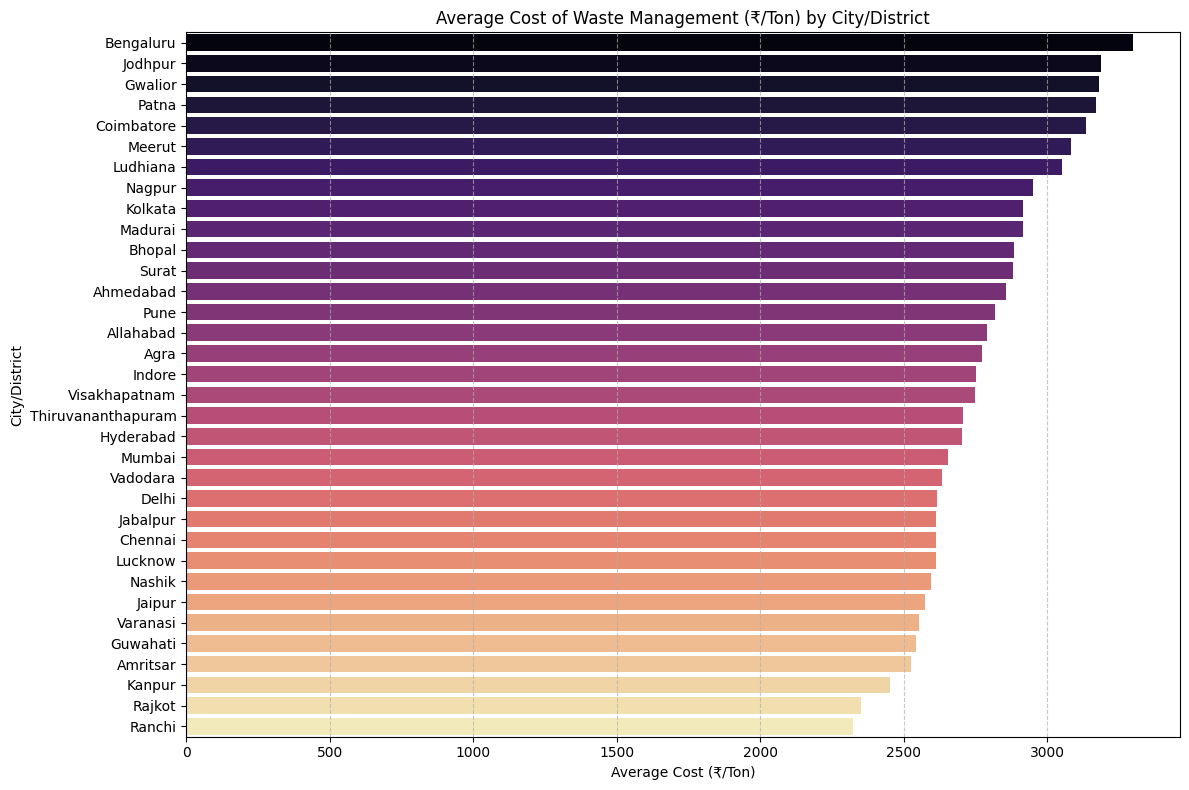


Top 5 Cities by Average Cost of Waste Management (most expensive):


,cost_of_waste_management_per_ton
citydistrict,
Bengaluru,3298.32
Jodhpur,3188.52
Gwalior,3182.08
Patna,3170.36
Coimbatore,3134.88



Bottom 5 Cities by Average Cost of Waste Management (least expensive):


,cost_of_waste_management_per_ton
citydistrict,
Guwahati,2542.28
Amritsar,2526.20
Kanpur,2453.44
Rajkot,2351.88
Ranchi,2321.92


In [12]:
# Calculate average cost of waste management per ton for each city/district
avg_cost_per_ton = df_waste.groupby('citydistrict')['cost_of_waste_management_per_ton'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=avg_cost_per_ton.values, y=avg_cost_per_ton.index, palette='magma', hue=avg_cost_per_ton.index, legend=False)
plt.title('Average Cost of Waste Management (₹/Ton) by City/District')
plt.xlabel('Average Cost (₹/Ton)')
plt.ylabel('City/District')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTop 5 Cities by Average Cost of Waste Management (most expensive):")
display(avg_cost_per_ton.head())

print("\nBottom 5 Cities by Average Cost of Waste Management (least expensive):")
display(avg_cost_per_ton.tail())

#### 4.6 Influence of Population Density and Awareness Campaigns on Recycling Rates

Let's examine how population density and the number of awareness campaigns correlate with recycling rates. These factors often play a significant role in the success of waste management programs.

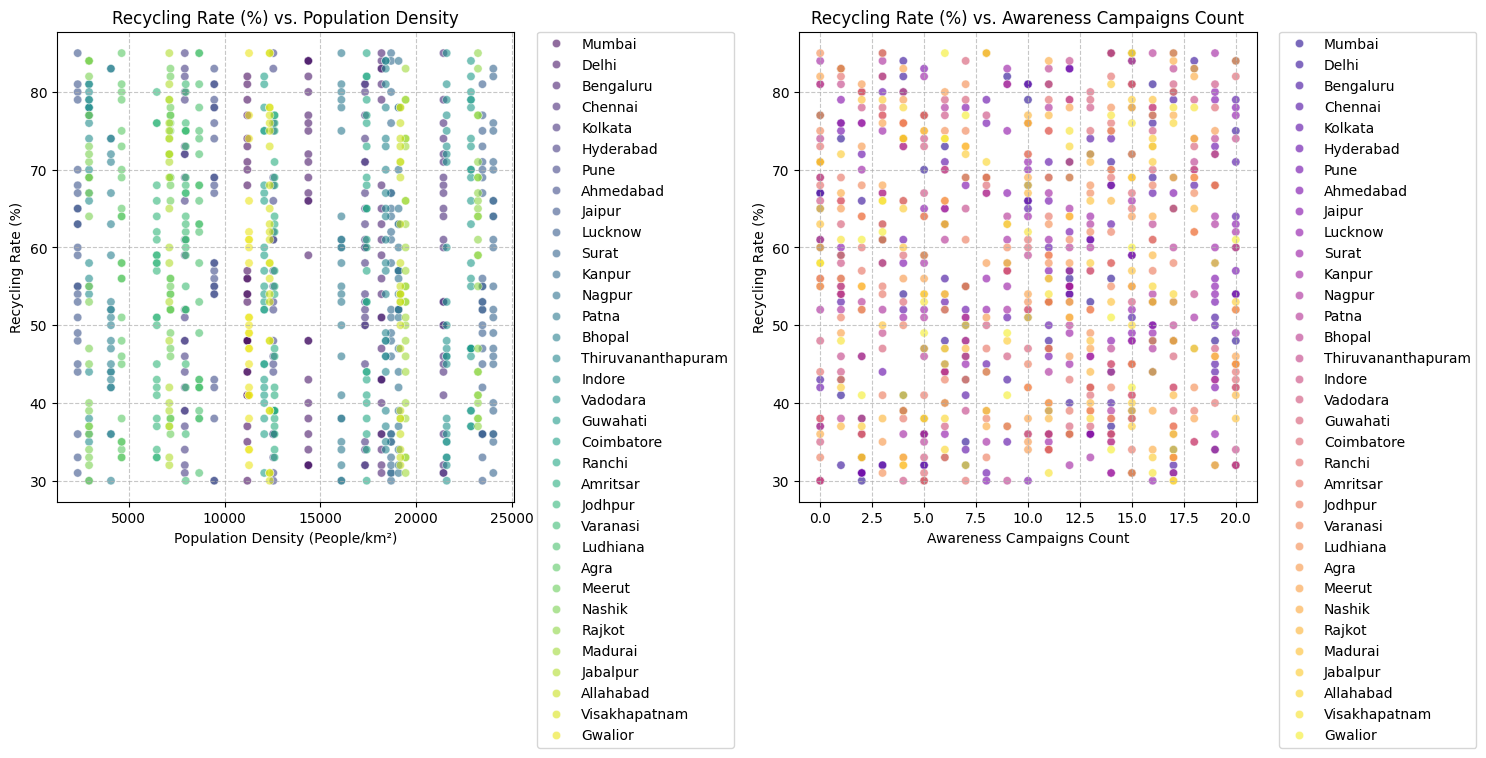


Correlation between Population Density and Recycling Rate: -0.05
Correlation between Awareness Campaigns Count and Recycling Rate: -0.02


In [13]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(x='population_density_people_per_km2', y='recycling_rate_percent', data=df_waste, alpha=0.6, hue='citydistrict', palette='viridis', legend='brief')
plt.title('Recycling Rate (%) vs. Population Density')
plt.xlabel('Population Density (People/km²)')
plt.ylabel('Recycling Rate (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.scatterplot(x='awareness_campaigns_count', y='recycling_rate_percent', data=df_waste, alpha=0.6, hue='citydistrict', palette='plasma', legend='brief')
plt.title('Recycling Rate (%) vs. Awareness Campaigns Count')
plt.xlabel('Awareness Campaigns Count')
plt.ylabel('Recycling Rate (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

# Calculate correlation coefficients
corr_population_density = df_waste['population_density_people_per_km2'].corr(df_waste['recycling_rate_percent'])
corr_awareness_campaigns = df_waste['awareness_campaigns_count'].corr(df_waste['recycling_rate_percent'])

print(f"\nCorrelation between Population Density and Recycling Rate: {corr_population_density:.2f}")
print(f"Correlation between Awareness Campaigns Count and Recycling Rate: {corr_awareness_campaigns:.2f}")

### Step 5: Summarizing Key Findings from EDA

Based on our comprehensive Exploratory Data Analysis, we can now synthesize the key findings related to regional recycling rates, material recovery, temporal trends, municipal efficiency, cost efficiency, and the influence of population density and awareness campaigns. These insights will inform our recommendations and the design of the interactive dashboard.

#### Summary of Findings:

1.  **Regional Recycling Rates (Section 4.1):**
    *   **Top Performers:** Indore, Ahmedabad, and Thiruvananthapuram consistently show the highest average recycling rates.
    *   **Bottom Performers:** Kanpur, Gwalior, and Vadodara exhibit the lowest average recycling rates, indicating significant regional disparities and potential areas for intervention.

2.  **Material Recovery Rates (Section 4.2):**
    *   **High Recovery:** Plastic waste generally has the highest recovery rate (approx. 58.49%), followed by Construction waste (approx. 56.85%).
    *   **Lower Recovery:** E-Waste appears to have the lowest recovery rate (approx. 55.75%), suggesting a potential bottleneck in the recycling of electronic waste materials.

3.  **National Trends Over Time (Section 4.3):**
    *   The national recycling rate has remained relatively stable (between 55% and 58%) from 2019 to 2023, despite fluctuations in total waste generated. This indicates a consistent, but not significantly improving, overall recycling effort.

4.  **Municipal Efficiency Impact (Section 4.4):**
    *   There is a very weak negative correlation (-0.03) between `municipal_efficiency_score` and `recycling_rate_percent`. This suggests that the current municipal efficiency metric may not be a strong predictor of recycling success, or other factors are more dominant.

5.  **Cost Efficiency Analysis (Section 4.5):**
    *   **Highest Costs:** Cities like Bengaluru, Jodhpur, and Gwalior incur the highest average costs for waste management per ton.
    *   **Lowest Costs:** Ranchi, Rajkot, and Kanpur demonstrate more cost-efficient waste management. These disparities highlight opportunities for learning best practices from lower-cost cities or investigating inefficiencies in higher-cost regions.

6.  **Influence of Population Density and Awareness Campaigns (Section 4.6):**
    *   Both population density (-0.05) and the count of awareness campaigns (-0.02) show very weak negative correlations with recycling rates. This indicates that merely increasing population density or the number of awareness campaigns, in isolation, might not be sufficient to drive higher recycling rates. The *quality* or *type* of campaigns, or other socio-economic factors, might be more important.

In [31]:
app_content = '''
import streamlit as st
import pandas as pd
import plotly.express as px
import numpy as np

def generate_synthetic_data():
    """Generates synthetic Indian municipal waste data."""
    cities = ['Mumbai', 'Delhi', 'Bengaluru', 'Chennai', 'Kolkata', 'Hyderabad', 'Pune', 'Ahmedabad', 'Jaipur', 'Lucknow']
    waste_types = ['Plastic', 'Organic', 'E-Waste', 'Construction', 'Hazardous']
    disposal_methods = ['Composting', 'Incineration', 'Landfill', 'Recycling']
    years = list(range(2019, 2024))

    data = []
    for year in years:
        for city in cities:
            for wt in waste_types:
                waste_generated = np.random.randint(1000, 10000)
                recycling_rate = np.random.randint(40, 70) # % for display, actual calc later
                population_density = np.random.randint(2000, 15000)
                municipal_efficiency = np.random.randint(1, 10)
                disposal = np.random.choice(disposal_methods)
                cost = np.random.randint(1500, 4000)
                awareness_campaigns = np.random.randint(0, 20)

                data.append({
                    'City/District': city,
                    'Waste Type': wt,
                    'Waste Generated (Tons/Day)': waste_generated,
                    'Recycling Rate (%)': recycling_rate,
                    'Population Density (People/km²)': population_density,
                    'Municipal Efficiency Score (1-10)': municipal_efficiency,
                    'Disposal Method': disposal,
                    'Cost of Waste Management (₹/Ton)': cost,
                    'Awareness Campaigns Count': awareness_campaigns,
                    'Year': year
                })
    df = pd.DataFrame(data)
    # No cleaning here, it will be done universally below.
    return df

# --- Streamlit App Layout and Logic ---

st.set_page_config(layout="wide", page_title="India Waste Recycling Rate Analysis")
st.title("🇮🇳 India Waste Recycling Rate Analysis Dashboard")

st.markdown("Upload your `Waste_Management_and_Recycling_India.csv` file, or use synthetic data.")

uploaded_file = st.sidebar.file_uploader("Choose a CSV file", type="csv")

if uploaded_file is not None:
    df_waste = pd.read_csv(uploaded_file)
    st.sidebar.success("Data loaded from uploaded CSV!")
else:
    df_waste = generate_synthetic_data()
    st.sidebar.info("No CSV uploaded. Using synthetic data for demonstration.")

# --- Universal Data Cleaning and Preprocessing ---
# Apply general cleaning to column names for both uploaded and synthetic data
df_waste.columns = df_waste.columns.str.replace(r'[^a-zA-Z0-9_\\s]', '', regex=True)
df_waste.columns = df_waste.columns.str.lower()
df_waste.columns = df_waste.columns.str.replace(' ', '_', regex=False)

# Explicitly rename columns for consistency, handling potential variations
df_waste = df_waste.rename(columns={
    'waste_generated_tonsday': 'waste_generated_tons_day',
    'recycling_rate_': 'recycling_rate_percent', # From 'Recycling Rate (%)' becoming 'recycling_rate_'
    'recycling_rate': 'recycling_rate_percent', # For cases where original might be 'Recycling Rate' -> 'recycling_rate'
    'population_density_peoplekm': 'population_density_people_per_km2',
    'cost_of_waste_management_ton': 'cost_of_waste_management_per_ton',
    'municipal_efficiency_score_110': 'municipal_efficiency_score'
}, errors='ignore') # Use errors='ignore' to prevent KeyError if a column name isn't found for renaming

# Calculate 'recycled_waste_tons_day' for each row
# This line should now find 'recycling_rate_percent' reliably
df_waste['recycled_waste_tons_day'] = df_waste['waste_generated_tons_day'] * (df_waste['recycling_rate_percent'] / 100)

# --- Sidebar Filters ---
st.sidebar.header("Filters")

# Year Filter
all_years = sorted(df_waste['year'].unique())
years_selected = st.sidebar.multiselect("Select Year(s)", all_years, default=all_years)

# Waste Type Filter
all_waste_types = sorted(df_waste['waste_type'].unique())
waste_types_selected = st.sidebar.multiselect("Select Waste Type(s)", all_waste_types, default=all_waste_types)

# City Filter
all_cities = sorted(df_waste['citydistrict'].unique())
cities_selected = st.sidebar.multiselect("Select City/District(s)", all_cities, default=all_cities)

# Apply filters
df_filtered = df_waste[
    (df_waste['year'].isin(years_selected)) &
    (df_waste['waste_type'].isin(waste_types_selected)) &
    (df_waste['citydistrict'].isin(cities_selected))
]

if df_filtered.empty:
    st.warning("No data available for the selected filters. Please adjust your selections.")
else:
    # --- Key Metrics Summary ---
    st.header("Key Metrics Summary")

    total_waste_processed = df_filtered['waste_generated_tons_day'].sum()
    total_recycled_waste = df_filtered['recycled_waste_tons_day'].sum()
    overall_recycling_rate = (total_recycled_waste / total_waste_processed) * 100 if total_waste_processed > 0 else 0
    avg_municipal_efficiency = df_filtered['municipal_efficiency_score'].mean()

    col1, col2, col3 = st.columns(3)
    with col1:
        st.metric("Total Waste Processed (Tons/Day)", f"{total_waste_processed:,.0f}")
    with col2:
        st.metric("Overall Recycling Rate (%)", f"{overall_recycling_rate:,.2f}%")
    with col3:
        st.metric("Avg. Municipal Efficiency Score", f"{avg_municipal_efficiency:,.2f}")

    # --- City Leaderboard ---
    st.markdown("--- ")
    st.header("City/District Recycling Performance Leaderboard")

    regional_waste_summary = df_filtered.groupby(['citydistrict', 'year']).agg(
        total_waste_generated_tons_day=('waste_generated_tons_day', 'sum'),
        total_recycled_waste_tons_day=('recycled_waste_tons_day', 'sum')
    ).reset_index()

    regional_waste_summary['regional_recycling_rate_percent'] = (
        regional_waste_summary['total_recycled_waste_tons_day'] / regional_waste_summary['total_waste_generated_tons_day']
    ) * 100

    avg_regional_recycling = regional_waste_summary.groupby('citydistrict')['regional_recycling_rate_percent'].mean().sort_values(ascending=False).reset_index()
    avg_regional_recycling.columns = ['City/District', 'Average Recycling Rate (%)']

    fig_city_leaderboard = px.bar(
        avg_regional_recycling,
        x='Average Recycling Rate (%)',
        y='City/District',
        orientation='h',
        title='Average Recycling Rate by City/District',
        color='Average Recycling Rate (%)',
        color_continuous_scale=px.colors.sequential.Viridis
    )
    fig_city_leaderboard.update_layout(yaxis={'categoryorder':'total ascending'})
    st.plotly_chart(fig_city_leaderboard, use_container_width=True)

    # --- Material Breakdown ---
    st.markdown("--- ")
    st.header("Material Recovery Rate Breakdown")

    material_recovery_summary = df_filtered.groupby('waste_type').agg(
        total_waste_generated_material=('waste_generated_tons_day', 'sum'),
        total_recycled_waste_material=('recycled_waste_tons_day', 'sum')
    ).reset_index()

    material_recovery_summary['material_recovery_rate_percent'] = (
        material_recovery_summary['total_recycled_waste_material'] / material_recovery_summary['total_waste_generated_material']
    ) * 100

    material_recovery_summary_sorted = material_recovery_summary.sort_values(by='material_recovery_rate_percent', ascending=False)

    fig_material_breakdown = px.bar(
        material_recovery_summary_sorted,
        x='material_recovery_rate_percent',
        y='waste_type',
        orientation='h',
        title='Material Recovery Rate (%) by Waste Type',
        color='material_recovery_rate_percent',
        color_continuous_scale=px.colors.sequential.Plasma
    )
    fig_material_breakdown.update_layout(yaxis={'categoryorder':'total ascending'})
    st.plotly_chart(fig_material_breakdown, use_container_width=True)
'''

# Save the Streamlit app definition to a file
with open('app.py', 'w') as f:
    f.write(app_content)

print("New Streamlit app (app.py) created with dashboard features. Please run the next cell to launch it.")

New Streamlit app (app.py) created with dashboard features. Please run the next cell to launch it.


In [29]:
# Install Streamlit and pyngrok if not already installed (ensure they are recent)
!pip install -q streamlit pyngrok --upgrade

import threading
import time
import os
from pyngrok import ngrok

# Terminate any existing ngrok tunnels to avoid conflicts
ngrok.kill()

# --- Set your ngrok authentication token ---
# IMPORTANT: Use the token provided by the user.
ngrok.set_auth_token("3K04fapT3pDEajygJgPwoR7Su9v_6sSzyKoRpFzMbkuAdgbka")

def run_streamlit_app():
    # Streamlit requires its own command to run, and we tell it to use a specific port
    # and disable browser opening (which won't work in Colab anyway).
    os.system("streamlit run app.py --server.port 8501 --server.enableCORS false --server.enableXsrfProtection false --browser.gatherUsageStats false")

# Start Streamlit in a new thread
print("Starting Streamlit app in a separate thread...")
streamlit_thread = threading.Thread(target=run_streamlit_app)
streamlit_thread.daemon = True # Allow the main program to exit even if the thread is still running
streamlit_thread.start()

# Give Streamlit a moment to start up on port 8501
time.sleep(10) # Increased sleep time for robustness

# Attempt to establish ngrok tunnel to Streamlit's port (8501)
print("Attempting to establish ngrok tunnel for Streamlit...")
public_url_streamlit = None
try:
    # ngrok.connect will use the auth token set globally by ngrok.set_auth_token()
    public_url_streamlit = ngrok.connect(8501)
    print(f"\nStreamlit app is now publicly accessible at: {public_url_streamlit}")
    print("Click the URL above to view your interactive dashboard!")
except Exception as e:
    print(f"Failed to establish ngrok tunnel for Streamlit: {e}")
    print("This might be due to an incorrect auth token, network issues, or ngrok service problems.")
    print("Please check your ngrok token and network connection, then try rerunning the cell.")

print("\nStreamlit app is running (or attempted to start). Look for the public URL above.")

Starting Streamlit app in a separate thread...
Attempting to establish ngrok tunnel for Streamlit...

Streamlit app is now publicly accessible at: NgrokTunnel: "https://starch-work-luminance.ngrok-free.dev" -> "http://localhost:8501"
Click the URL above to view your interactive dashboard!

Streamlit app is running (or attempted to start). Look for the public URL above.
